# 04 · Capability coverage — Knowledge vs Analytical ($\mathcal{F}_1(\mathcal{D})$)

Do these benchmarks test reasoning, or mostly factual recall? We classify a
stratified sample of every task's questions as **Knowledge** or **Analytical**
(multi-model vote) and break it down per task/parent.


In [1]:
import nbtools as nb
from nbtools import show_df, show_fig, show_md, run_mod, heavy, REGEN, REPORTS_DIR
print("SAYF_NB_REGEN =", REGEN, "  (heavy GPU/API steps run only when True)")
print("reports dir  :", REPORTS_DIR)

SAYF_NB_REGEN = False   (heavy GPU/API steps run only when True)
reports dir  : /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports


### Build the K/A sample bank — `analysis.build_ka_bank`

In [2]:
run_mod("build_ka_bank", "analysis.build_ka_bank")

  [ate] picked 55 / 55
  [rcm] picked 100 / 995


  [vsp] picked 100 / 995


  [ckt] picked 100 / 3000
  [rms] picked 100 / 500
  [taa] picked 100 / 100
  [cti_taa] picked 50 / 50


  [mcq] picked 100 / 2495
  [athena_ate] picked 100 / 500
  [athena_rcm] picked 100 / 2000


  [athena_vsp] picked 100 / 2000
  [secure_maet] picked 100 / 1067
  [secure_cwet] picked 100 / 959


...

  [redsage_generals] picked 100 / 5000


  [redsage_skills] picked 100 / 10000
  [redsage_cli] picked 100 / 5000


  [redsage_kali] picked 100 / 5000
  [cybermetric] picked 100 / 500
  [mmlu_cs] picked 100 / 100
  [secbench] picked 100 / 647


  [seceval] picked 100 / 2189
  [sevenllm] picked 100 / 650

wrote 2305 samples -> /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports/coverage/sample_bank.jsonl
[build_ka_bank] recomputed live.


True

### Classify K vs A — `analysis.classify_ka`  *(heavy · Azure/vLLM)*
Off by default — rendered from cached verdicts. `SAYF_NB_REGEN=1` to re-run.


In [3]:
if heavy("classify_ka"):
    run_mod("classify_ka", "analysis.classify_ka")

[classify_ka] heavy step skipped — rendering cached artifact. Set SAYF_NB_REGEN=1 to recompute (needs GPU/API key).


### Aggregate — `analysis.aggregate_ka`
Majority K/A + inter-rater agreement (Cohen's / Fleiss' κ).

In [4]:
run_mod("aggregate_ka", "analysis.aggregate_ka")
show_df("coverage/per_parent_breakdown.csv")
show_df("coverage/per_task_breakdown.csv")
show_md("coverage/summary.md")

wrote /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports/coverage/per_sample_verdicts.csv, per_task_breakdown.csv, per_parent_breakdown.csv, agreement.csv, summary.md
  Fleiss's κ = 0.753
[aggregate_ka] recomputed live.


,parent,n_samples,K,A,ambiguous,K_pct,A_pct
0,CTI,355,96,255,4,27.0,71.8
1,ATHENA,600,36,527,37,6.0,87.8
2,SECURE,300,199,93,8,66.3,31.0
3,REDSAGE,500,486,3,11,97.2,0.6
4,CYBERMETRIC,100,97,1,2,97.0,1.0
5,MMLU-CS,100,97,0,3,97.0,0.0
6,SecBench,100,91,4,5,91.0,4.0
7,SecEval,100,32,42,26,32.0,42.0
8,SEVENLLM,0,0,0,0,0.0,0.0


,task,parent,n_samples,K,A,ambiguous,abstain,K_pct,A_pct
0,ate,CTI,55,0,55,0,0,0.0,100.0
1,rcm,CTI,100,0,100,0,0,0.0,100.0
2,vsp,CTI,100,0,100,0,0,0.0,100.0
3,ckt,ATHENA,100,36,27,37,0,36.0,27.0
4,rms,ATHENA,100,0,100,0,0,0.0,100.0
5,taa,ATHENA,100,0,100,0,0,0.0,100.0
6,cti_taa,CTI,0,0,0,0,0,0.0,0.0
7,mcq,CTI,100,96,0,4,0,96.0,0.0
8,athena_ate,ATHENA,100,0,100,0,0,0.0,100.0
9,athena_rcm,ATHENA,100,0,100,0,0,0.0,100.0


# K-vs-A coverage classification — summary

- bank: **2155** samples (~100 per sub-task; ate has 55, taa 100, mmlu_cs 100).
- models (top-4 by overall accuracy from §3.2.1; Llama-3.3-70B-Instruct substituted for Gemma-4-31B-it which is not locally cached):
  - GPT-5.4: 2155 verdicts cached
  - Qwen3.6-35B-A3B: 2155 verdicts cached
  - RedSage-Qwen3-8B-DPO: 2155 verdicts cached
  - Llama-3.3-70B-Instruct: 2155 verdicts cached

## Inter-model agreement

| pair | n | Cohen's κ |
|---|---|---|
| GPT-5.4 ↔ Qwen3.6-35B-A3B | 2155 | 0.658 |
| GPT-5.4 ↔ RedSage-Qwen3-8B-DPO | 2155 | 0.8336 |
| GPT-5.4 ↔ Llama-3.3-70B-Instruct | 2155 | 0.8716 |
| Qwen3.6-35B-A3B ↔ RedSage-Qwen3-8B-DPO | 2155 | 0.6734 |
| Qwen3.6-35B-A3B ↔ Llama-3.3-70B-Instruct | 2155 | 0.6662 |
| RedSage-Qwen3-8B-DPO ↔ Llama-3.3-70B-Instruct | 2155 | 0.8311 |

**Fleiss's κ (4 raters, n = 2155): 0.753**

## Per-parent K/A composition

| parent | n | K | A | ambiguous | K % | A % |
|---|---|---|---|---|---|---|
| CTI | 355 | 96 | 255 | 4 | 27.0 | 71.8 |
| ATHENA | 600 | 36 | 527 | 37 | 6.0 | 87.8 |
| SECURE | 300 | 199 | 93 | 8 | 66.3 | 31.0 |
| REDSAGE | 500 | 486 | 3 | 11 | 97.2 | 0.6 |
| CYBERMETRIC | 100 | 97 | 1 | 2 | 97.0 | 1.0 |
| MMLU-CS | 100 | 97 | 0 | 3 | 97.0 | 0.0 |
| SecBench | 100 | 91 | 4 | 5 | 91.0 | 4.0 |
| SecEval | 100 | 32 | 42 | 26 | 32.0 | 42.0 |
| SEVENLLM | 0 | 0 | 0 | 0 | 0 | 0 |

### Coverage figures — `analysis.make_coverage_plots`

wrote /export/home/aberriche/BenchBench/BenchmarkingSecBenchmarks/unified-benchmark-pipeline/analysis/reports/figures/coverage_main.png + coverage_main_ka.png + coverage_appendix.png
[make_coverage_plots] recomputed live.


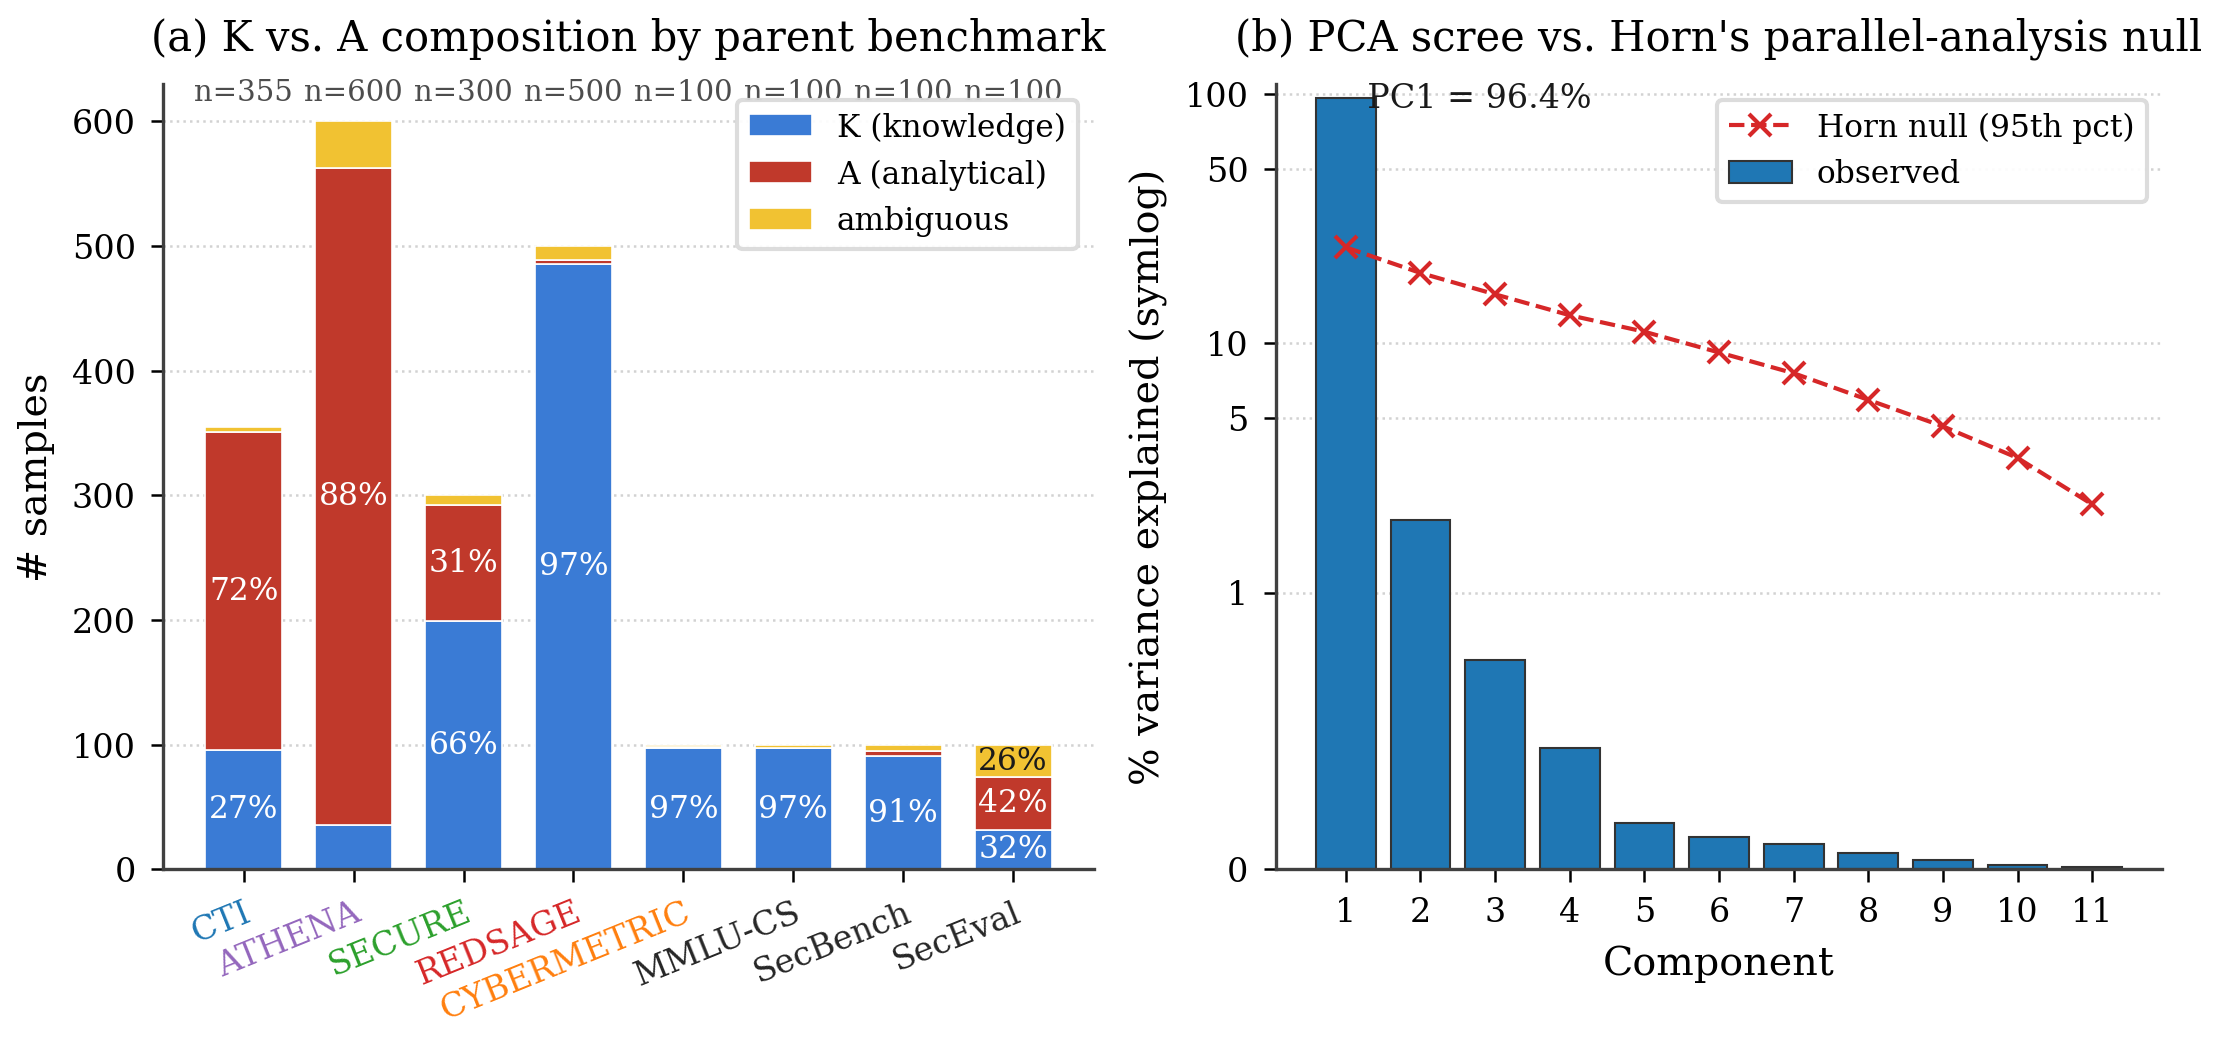

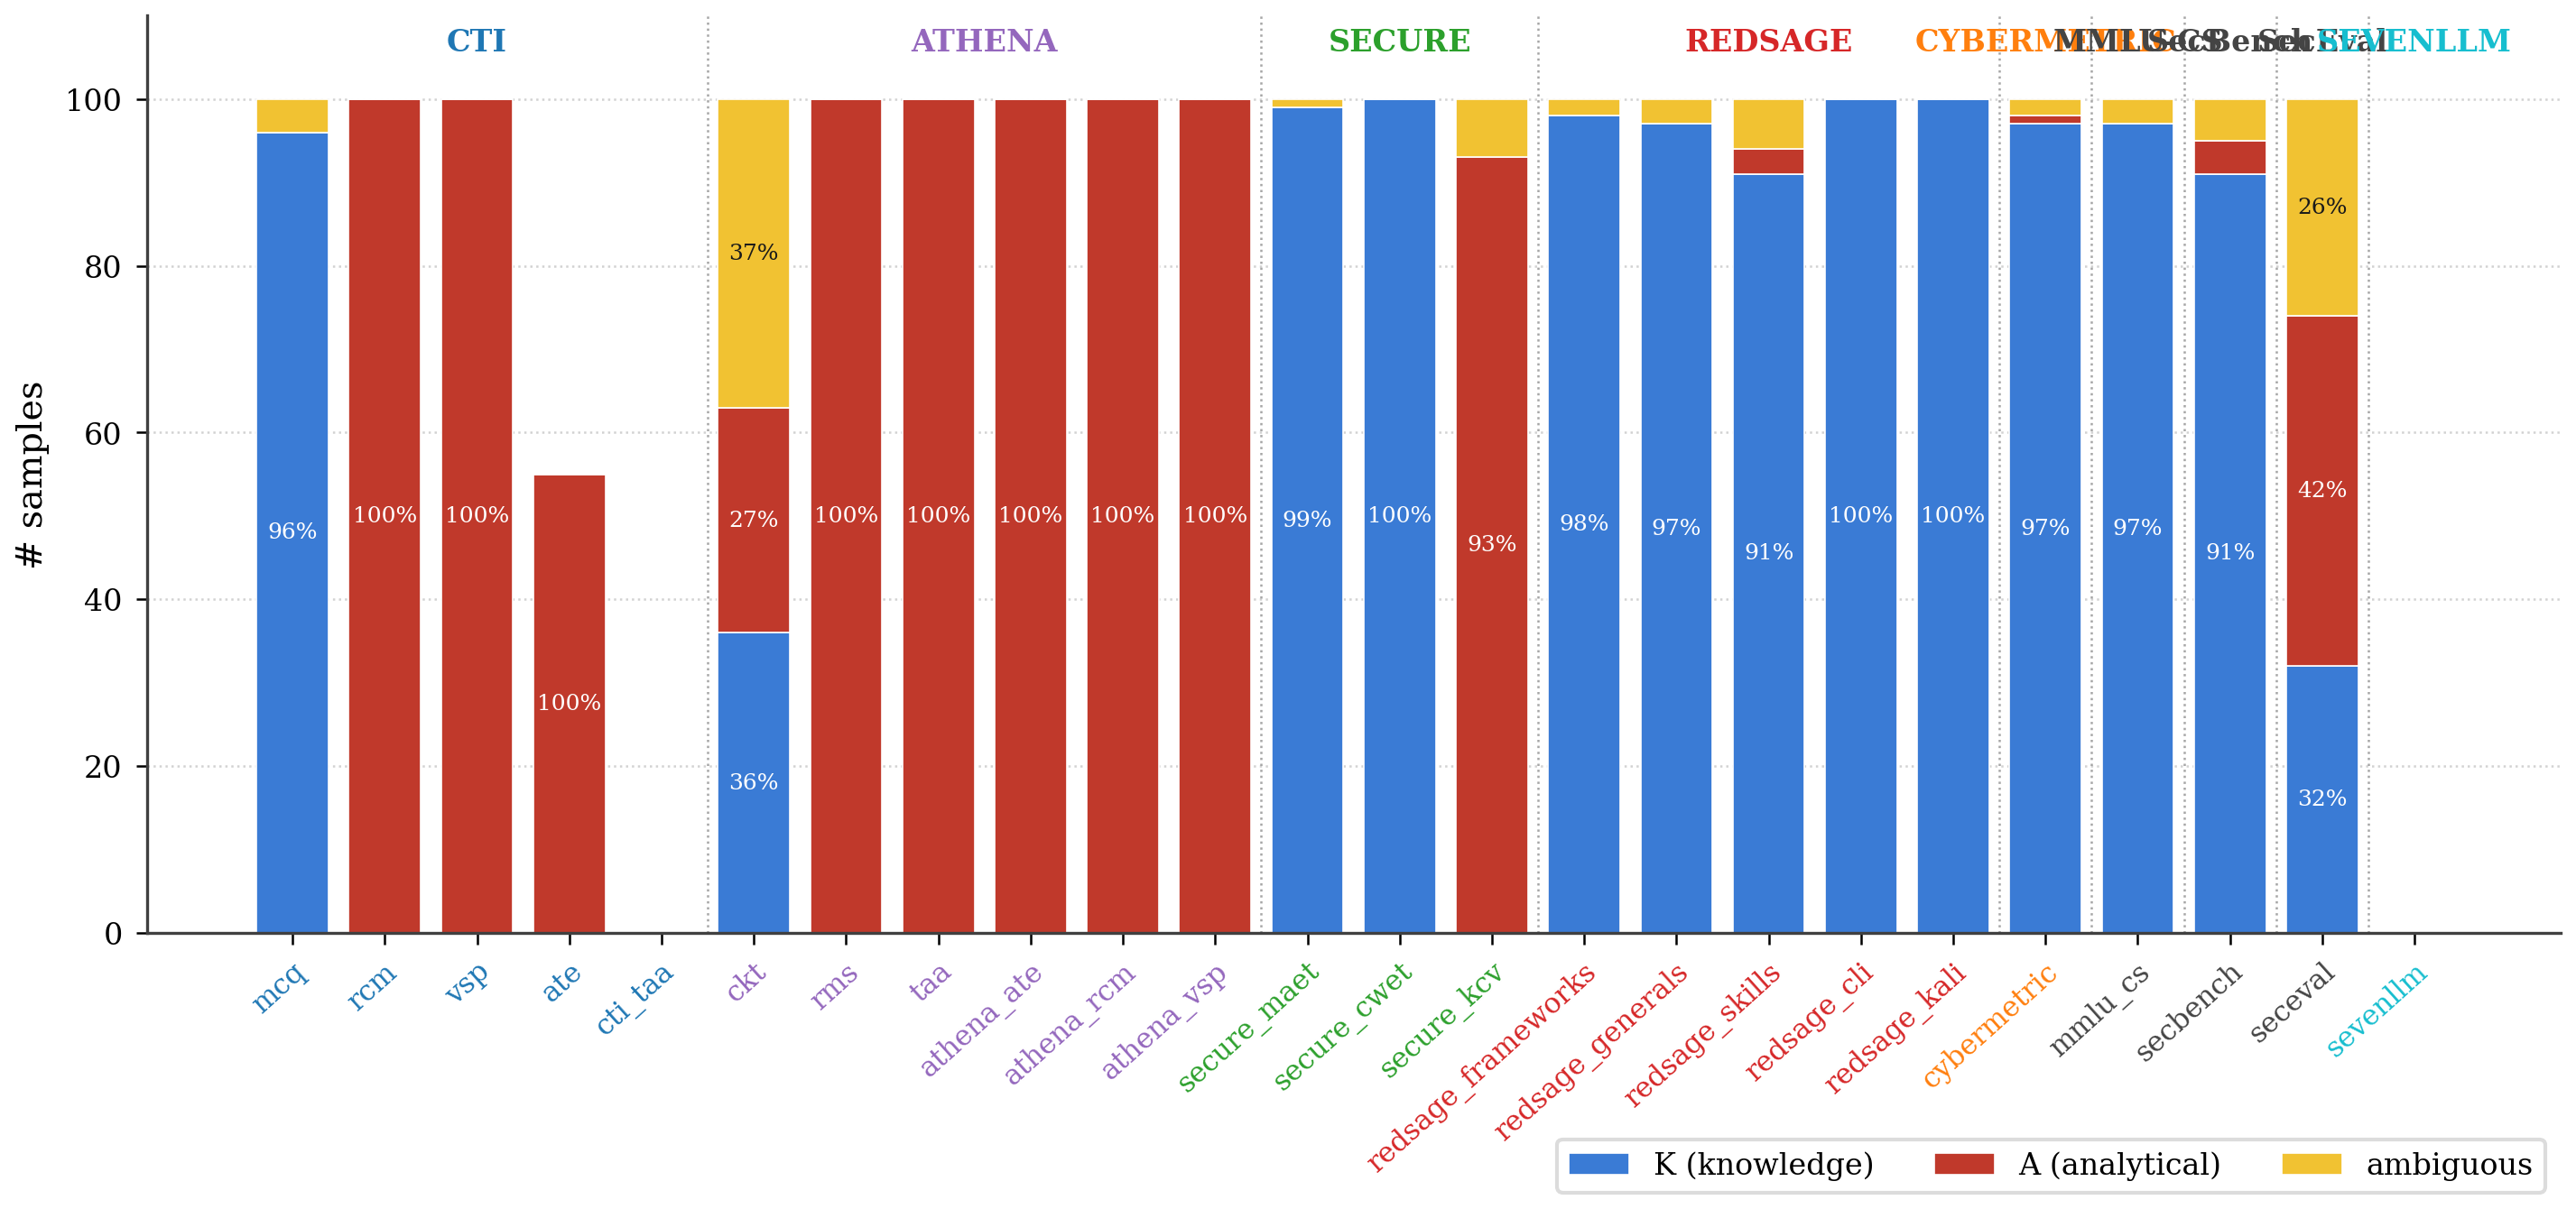

In [5]:
run_mod("make_coverage_plots", "analysis.make_coverage_plots")
show_fig("coverage_main.png")
show_fig("coverage_appendix.png")

_Shows the fraction of knowledge-oriented items per benchmark ($\\mathcal{F}_1(\\mathcal{D})$)._